###### UE ADSP

**A**nalogical and **D**igital **S**ignal **P**rocessing for sensor data

### TP 5 : Filter de Wiener

1. But du TP

Le but de ce TP consiste à tester le filtre de Wiener

Etapes :

- construction un chirp
- definir le filtre
- filtrer le signal bruité

Import des librairies

In [137]:
%matplotlib inline
import scipy
import matplotlib.pyplot as plt
import numpy as np

## Paramètre du signal

puissance du bruit : $SNR = O$
fréquence d'échantiollonnage : $fe = 5000 Hz$

In [138]:
SNR = 0  # dB
fs = 5000  # Sampling freq (Hz)

## Génération d'un signal contenant un Chirp et affichage

Un chirp (mot d'origine anglaise signifiant « gazouillis ») est par définition un signal pseudo-périodique $c$ modulé en fréquence autour d'une fréquence porteuse et également modulé en amplitude par une enveloppe $a$ dont les variations sont lentes par rapport aux oscillations de la phase $\phi$ :

$$ c(t)=a(t)e^{i\phi (t)}$$

La partie réelle de ce signal est tout simplement :

$$ \Re(c(t))=a(t)\cos {(2\pi f(t) t)}$$


Dans notre cas, l'évolution de $f(t)$ s'effectuera linéairement entre 2 valeurs ($f_0$ et $f_1$) et l'enveloppe sera réalisé par une fenêtre de Hanning.

Ici, 
$$f(t)=f_0+\beta t$$ 
avec 
$$\beta=\frac{f_1-f_0}{t_1}$$

où $t_1$ correspond à la durée du chirp.

- utilisation de la fonction [scipy.signal.chirp](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.chirp.html) pour générer le chirp.

La durée du signal contenant le chirp (nommé *sig_chirp*) de 2s. Il débutera par 0,75s de silence suivi par un chirp d'une durée de 1,25s.

N'oubliez pas de créer la base temporelle (*t*).

Le chirp débutera à une fréquence de $500$Hz et se terminera à une fréquence de $200$Hz. On multipliera la partie chirp par une fenêtre de hanning ([numpy.hanning](https://numpy.org/doc/stable/reference/generated/numpy.hanning.html)) de même durée que le chirp afin de créer une enveloppe autourde celui-ci.

- créer le "signal chirp"
- Afficher le "signal chirp" 

In [139]:
t_0, t_1, t_f = 0, 1.25, 2

N = (t_f-t_0)*fs
N_0 = int(1.25*N/2)
N_1 = N - N_0

f_0, f_1 = 500, 200

t = np.linspace(t_0, t_f, N_0)
sig_chirp = scipy.signal.chirp(t, f_0, t_1, f_1)
signale = np.zeros(N)
signale[N_1:] = np.hanning(len(sig_chirp))*sig_chirp

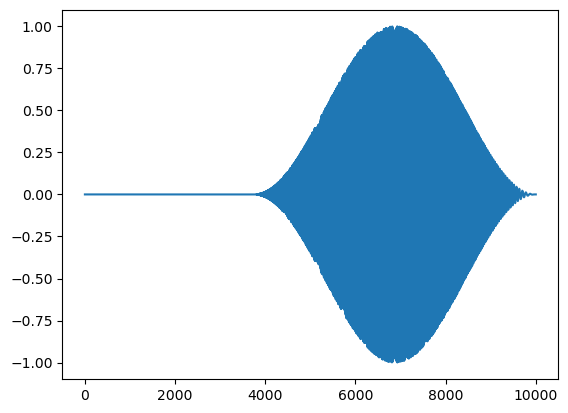

In [140]:
plt.plot(signale)

## Création du signal obervé et affichage

Le signal observé (*sig_obs*) correspond au signal chirp (*sig_chirp*) bruité.

Le bruit utilisé est un bruit blanc gaussien dont la puissance est donnée par *SNR*

On utilisera [numpy.random.normal](https://numpy.org/doc/2.1/reference/random/generated/numpy.random.normal.html)

Attention la buissance de bruit donnée en dB par la variable *SNR*.

- créer le signal chirp bruité puis afficher le.

- Faire également un zoom afin d'observer les oscillation d'une partie du chirp

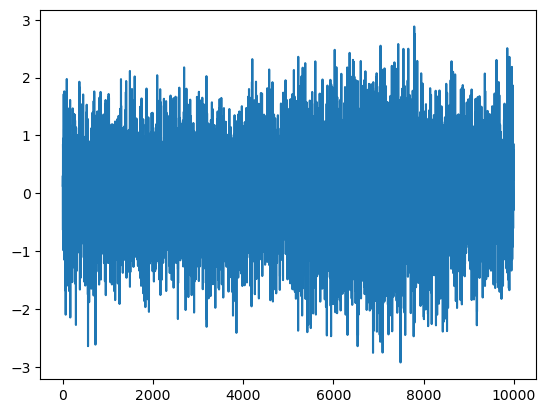

In [147]:
sigma = np.sqrt(np.var(sig_chirp))

bruit = np.random.normal(0, sigma, N)
sig_obs = signale + bruit
plt.plot(sig_obs)

## Création de la réponse fréquentielle du filtre de Wiener

On sait que le filtre de Wiener est défini par : 
$$\tilde{𝐻}(\nu)=\frac{\gamma_{𝑥}(\nu)}{\gamma_{𝑥}(\nu)+\gamma_b(\nu) }$$
De plus 
$$\gamma_{𝑥}(\nu)=\gamma_{y}(\nu)-\gamma_{b}(\nu)$$

$$\tilde{𝐻}(\nu)=1-\frac{\gamma_{b}(\nu)}{\gamma_{y}(\nu)}$$

Estimer $\gamma_{y}(\nu)$ (partie bruit sans signal) et $\gamma_b(\nu)$ (partie bruit + signal) à l'aide de *scipy.signal.welch*

en déduire l'estimée de $\gamma_{x}(\nu)$

puis l'estimée de $\tilde{𝐻}(\nu)$


**version un peu régularisée**  du filtre de Wiener (plus stable)
$$\epsilon=\min{(10^{-3},\gamma_x(\nu)/4)}$$


$$\tilde{𝐻}(\nu)=\max{(1-\frac{\gamma_{b}(\nu)+\epsilon}{\gamma_{y}(\nu)},0)}$$

- Le signal observé est composé d'une première partie (0,75s) qui ne contient que du bruit et d'une seconde partie qui correspond à la partie chirp bruité (1,25s).

Ces deux parties de l'observation seront utilisées pour créer les DSP nécessaire à la fabrique du filtre de Wiener.

- Création des DSP (bruit, signal bruité)
  - Utilisation de [scipy.signal.welch](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.welch.html) (nwin = 128, noverlap = 32)(attention afficher la DSP et adapter votre programme en conséquence)
 
  - densité du bruit et du signal Pbb_den, Pyy_den
 
  - Définir le gain filtre 

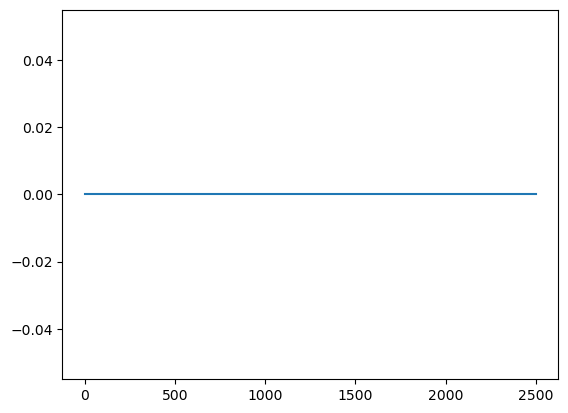

In [152]:
f, dsp_y = scipy.signal.welch(sig_obs, fs=fs)
f, dsp_x = scipy.signal.welch(signale, fs=fs)
dsp_b = sigma**2

eps = np.min(dsp_x/4)

filtre_estim = np.maximum(1 - (dsp_b+eps)/dsp_y,0)

plt.plot(f, np.abs(filtre_estim))

## Appliquer le filtre et afficher le rrésultat.

- appliquer le filtre au niveau fréquentiel
- effectuer une fft inverse
- afficher le résultat


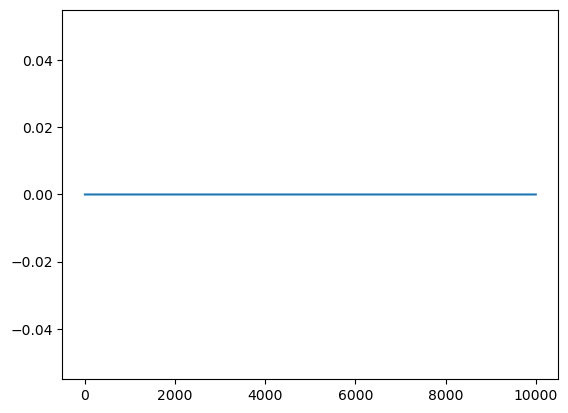

In [148]:
sig_rec = np.fft.irfft(
    np.fft.rfft(sig_obs) * np.interp(np.fft.rfftfreq(len(sig_obs), d=1/fs), f, filtre_estim),
    n=len(sig_obs)
)

plt.plot(sig_rec)

- Faire varier le bruit

- Décrire, commenter et analyser